In [1]:
%matplotlib inline

import sys

sys.path.append('..')

import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path
from itertools import product
from datetime import datetime
import os
import glob
import matplotlib.pyplot as plt
from open_ocean.utils import convert_climatology_to_ocean_areas
import open_ocean.gridder as gridder
import open_ocean.interpolation as io

In [2]:
def convert_dates(months, days):
    return [datetime(2020, months[i], days[i]) for i in range(len(months))]

In [3]:
def grid_selection(iquam, selection, climatology, sampling_unc, constant=None, separates=False):
    id = iquam.platform_id.values[selection]
    type = iquam.platform_type.values[selection]
    lats = iquam.lat.values[selection]
    lons = iquam.lon.values[selection]
    values = iquam.sst.values[selection]

    # Convert dates
    dates = convert_dates(
        iquam.month.values[selection].astype(int),
        iquam.day.values[selection].astype(int)
    )

    # Grid up the data
    grid = gridder.Grid(2020, 10, id, lats, lons, dates, values, type, climatology)
    grid.add_sampling_uncertainties(sampling_unc)
    grid.do_1x1_gridding()
    grid.do_one_step_5x5_gridding()
    biascov = grid.calculate_covariance(constant=constant, separates=True)

    if separates:
        return grid, biascov

    return grid

Bias estimation
===============

One thing we can use the Gaussian Proces interpolation for is to estimate biases in the ship data at a global and ship-by-ship scale. The process is to first grid up the ship and drifter data separately and then sequentially assimilate the buoy and ship observations. The drifter data provides an initial unbiased estimate of the global field. The ship data are then assimilated and the resulting field is effectively bias adjusted.

In [4]:
data_dir = Path(os.getenv("OODIR"))
coder = xr.coders.CFDatetimeCoder(time_unit="s")

In [5]:
climatology = xr.open_dataset(data_dir / "SST_CCI_climatology" / "SST_1x1_daily.nc")
areas = convert_climatology_to_ocean_areas(climatology)
sampling_unc = xr.open_dataset(data_dir / "IQUAM" / "OutputData" / "sampling_uncertainty.nc")

In [6]:
year = 2008
month = 7
file = data_dir / 'IQUAM' / f'{year}{month:02d}-STAR-L2i_GHRSST-SST-iQuam-V2.10-v01.0-fv01.0.nc'
iquam = xr.open_dataset(file, decode_timedelta=coder)

quality = iquam.quality_level.values
selection = (quality >= 4)

grid = grid_selection(iquam, selection, climatology, sampling_unc)


Ship data
=========

First I grid up the ship data. I add a constant term to the error covariance to represent a global bias common to all ships. The uncertainty associated with this is set to 0.2K, which is larger than the bias likely is but is roughly the right order of magnitude.

The map of gridded anomalies from ships shows some interesting features. There is a short El Nino warm tongue in the eastern Pacific. The North Atlantic looks to be largely warmer than the average. There is a strong warm anomaly in the western North Pacific with cooler anomalies in the east. In the southeast Pacific there is a lonely ship track with a very positive anomaly. This is likely erroneous.

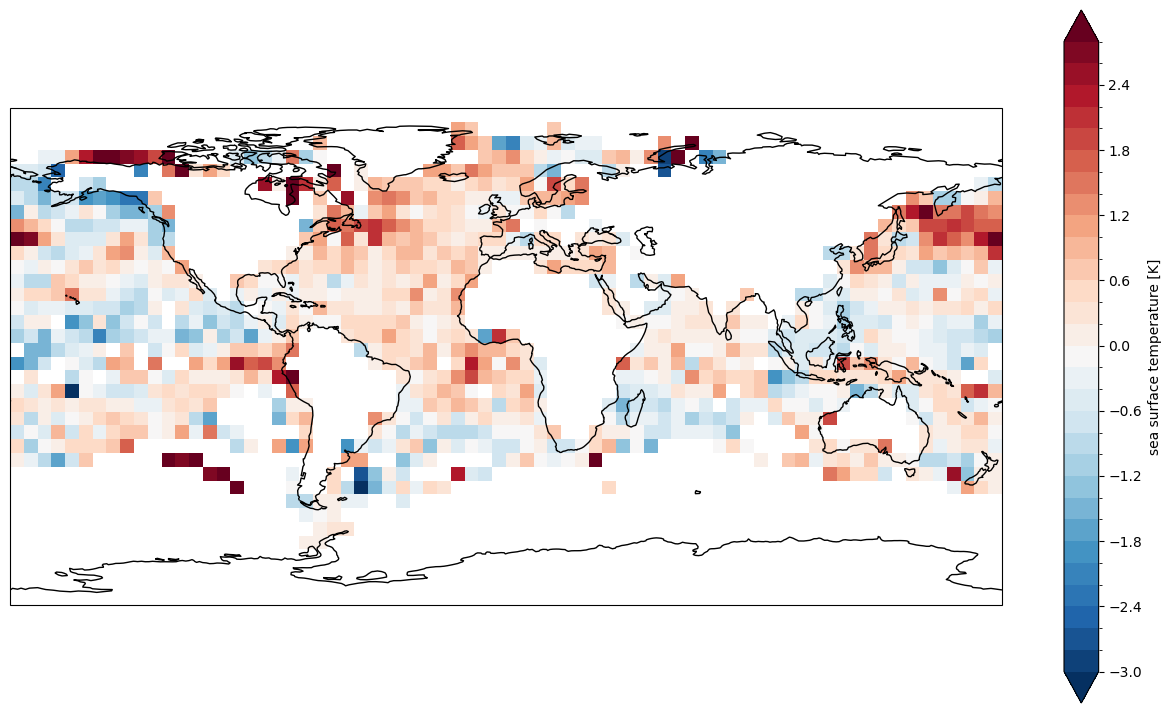

In [7]:
selection = (quality >= 4) & (iquam.platform_type.values == 1)
ship_grid, ship_bias_cov = grid_selection(iquam, selection, climatology, sampling_unc, constant=0.2, separates=True)
ship_grid.plot_map_5x5()

Drifter data
============

I grid the drifter data, but in this case, I haven't added a constant to the error covariance reflecting the fact (my belief anyway) that drifters are unbiased. If you're worried about that, we can just say that the "true" SST is whatever drifting buoys measure on average. The error covariances still allow for biases in individual buoys, but the mean bias is assumed to be zero.

While the coverage of drifting buoy observations is more complete than for ships there are still significant gaps, including in the tropical Pacific. This is why it can be important to use ship data despite the fact that it is less reliable than drifter data. It still contains useufl information. In this case, ships provide information which will help to reconstruct the El Nino. On the other hand, the drifter anomalies in the Atlantic are clearly cooler on average than the ship data so the drifters will help there.

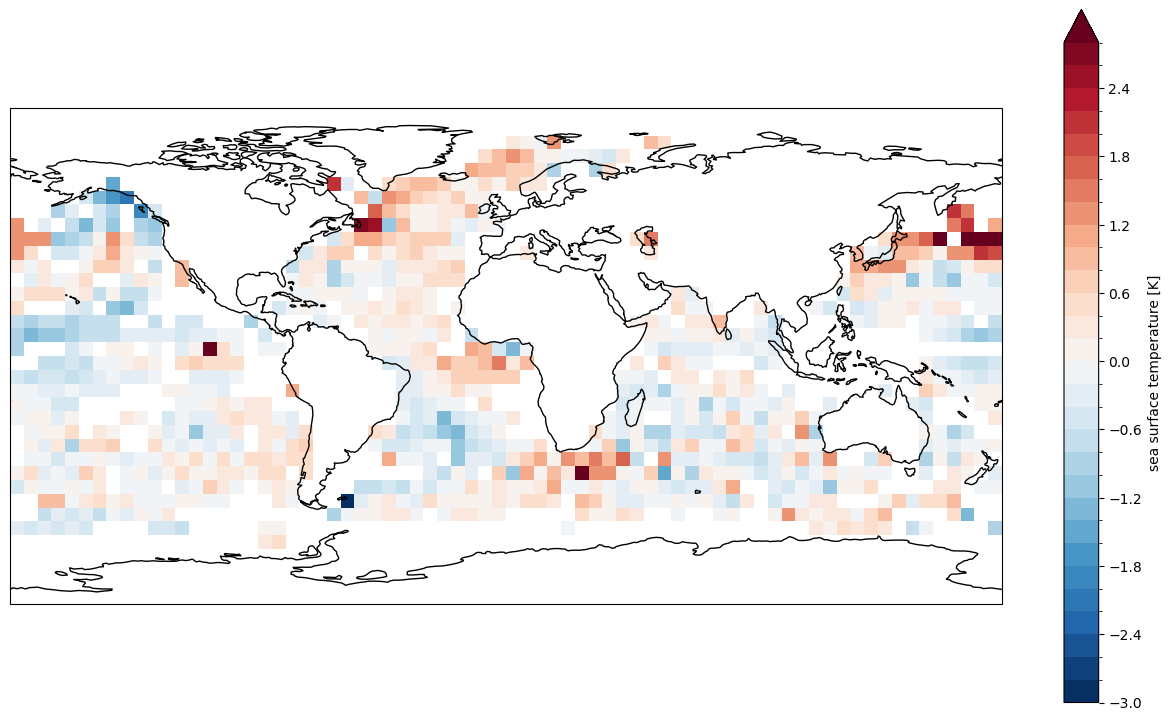

In [8]:
selection = (quality >= 4) & (iquam.platform_type.values == 2)
drifter_grid = grid_selection(iquam, selection, climatology, sampling_unc)
drifter_grid.plot_map_5x5()

Interpolation step 1
====================

I set up the Gaussian Process and then interpolate the drifter data. As with the ship data, I add a constant term to the prior covariance for the reconstruction, which represents a "global mean" temperature. Once the interpolation is done, I mask the land areas out for plotting.

In [9]:
kernel = io.Kernel(0.6, 1300.0, 1.5)
interp1 = io.GPInterpolator(drifter_grid, kernel)
interp1.make_covariance(constant=0.2)
interpolated_grid1 = interp1.do_interpolation()
interpolated_grid1.data5[np.isnan(sampling_unc.sst.values[0:1, :, :])] = np.nan

C:\Users\johnk\PycharmProjects\open-ocean\open_ocean\interpolation.py:37: RuntimeWarning: invalid value encountered in multiply
  (self.variance ** 2) *


The interpolated drifter data have most of the same features as the basic gridded drifter data. They're just a bit smoother and there are no gaps.

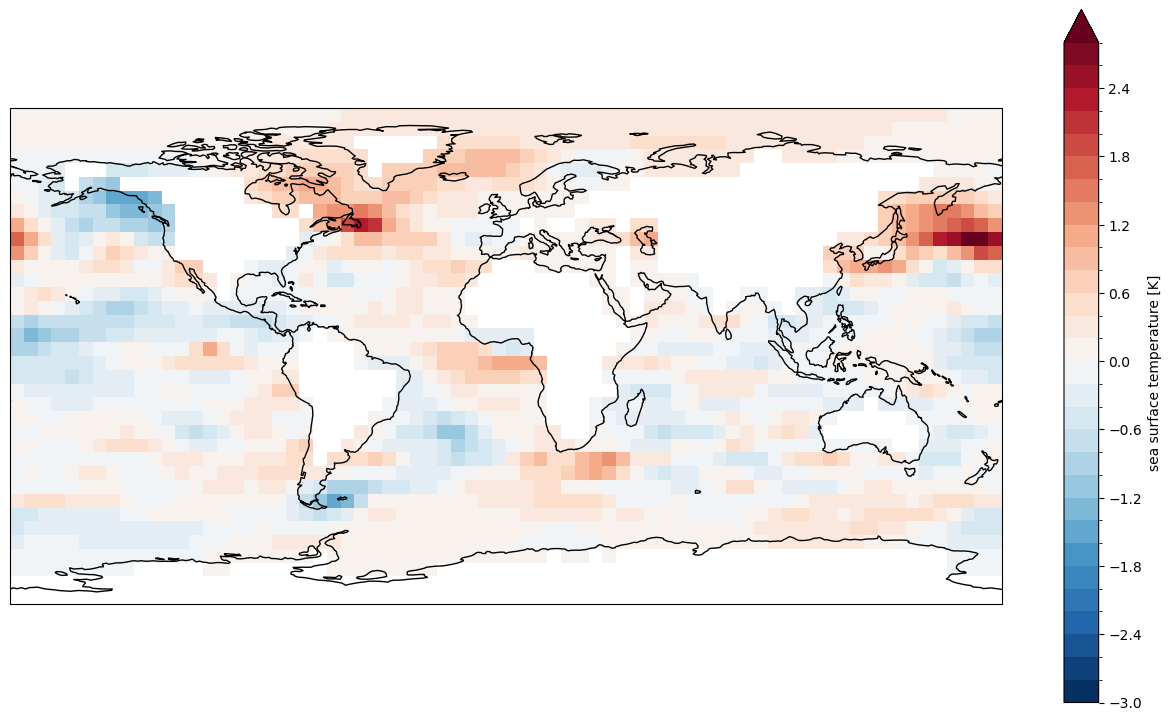

In [10]:
interpolated_grid1.plot_map_5x5()

Interpolation step 2
====================

Next I subtract the first interpolation from the ship data. I then use the posterior distribution from the first step of interpolation as a prior for the second step. I then do the interpolation of the ship data and add the interpolated ship data back onto the first interpolation step.

In [11]:
ship_grid = ship_grid - interpolated_grid1

kernel = io.Kernel(0.6, 1300.0, 1.5)
interp2 = io.GPInterpolator(ship_grid, kernel)
interp2.add_covariance(interp1.posterior)
interpolated_grid2 = interp2.do_interpolation()

interpolated_grid2.data5[np.isnan(sampling_unc.sst.values[0:1, :, :])] = np.nan
interpolated_grid2 = interpolated_grid2 + interpolated_grid1

ship_bias_grid = interp2.project_covariance(ship_bias_cov)
ship_bias_grid.data5[np.isnan(sampling_unc.sst.values[0:1, :, :])] = np.nan


The second interpolation step isn't that different from the first suggesting that the ship data are not adding a great deal of information. However, they are providing some information in the tropical Pacific. There are other minor changes.

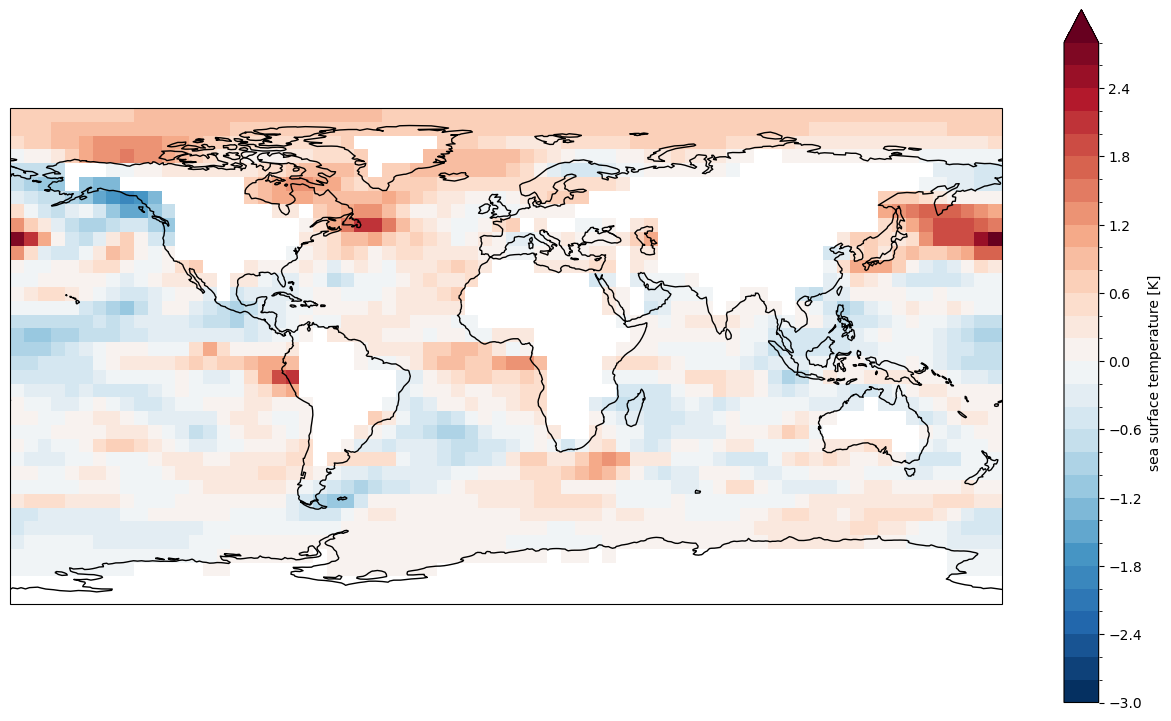

In [12]:
interpolated_grid2.plot_map_5x5()

Estimated ship errors
=====================

In principle, we can explicitly estimate each component of the ship errors: large scale bias, ship by ship bias, measurement error and sampling error. Each one is just a component of the overall variance. Mathematically, they're not different from the covariances describing the actual SST field, so just as we can estimate that using this technique, we can estimate the errors. However, I haven't done that. I've just taken the difference between the gridded ship data and the second step reconstruction. It's shown below.

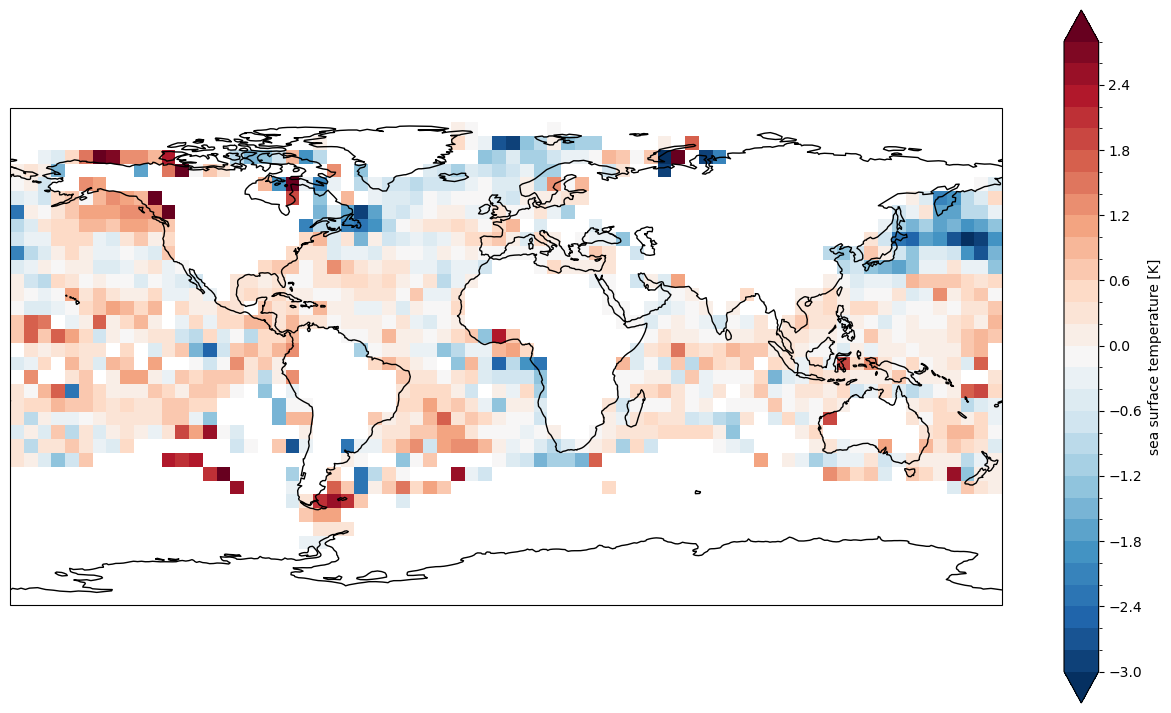

In [13]:
ship_error = ship_grid - interpolated_grid2
ship_error.plot_map_5x5()

First off, you can see the pervasive warm bias. There's noise because a lot of the error terms are noisy. On the other hand, the ship track joining the Panama Canal to Australia and New Zealand shows up as a swath of positive biases. To the south of that, as expected, the solitary ship in the southeast Pacific as a clear warm bias, but you can also see a cold biased ship which track from the southern tip of South America, slighly west of North up to Central America.

A similar result can be had by just taking the difference between the gridded ship and drifter data. However, the field is less complete, noisier because it includes noise from the drifter data too, and therefore we're not making full use of the available information.

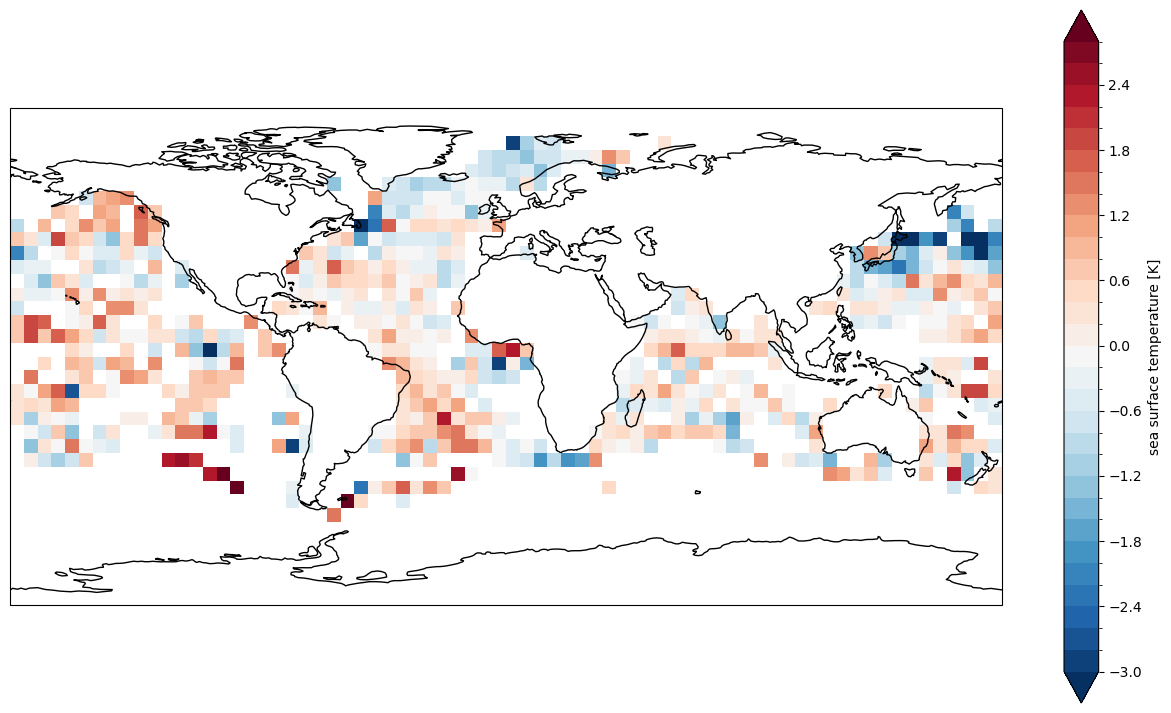

In [14]:
ship_error_simple = ship_grid - drifter_grid
ship_error_simple.plot_map_5x5()

Doing it properly
=================

OK, so, I calculated the bias components of the ship error on their own. It looks like this ⬇️. I narrowed the colour scale (it now runs from -1 to +1 rather than -3 to +3) to better show off the features. With the noise from uncorrelated measurement and sampling errors removed, you can clearly see the ship tracks criss-crossing the various ocean basins. The pale pink background is associated with the constant term in the error covariance and represents the "global bias" term.

This still doesn't quite have the rich spectrum of biases that exists in the real world. We know, for example, that errors correlate at the level of individual data collections (in ICOADS these were called "decks" meaning decks of punched cards on which the data were stored) or country of registration. I don't have that information in IQUAM. Also, SST biases can be subdivided into biases associated with different measurement methods, but IQUAM doesn't have that metadata either. Even within one measurement method there might be different kinds of bias behaviour. Some ships making measurements in their engine rooms have biases that are correlated with the SST. It's easy enough to add these terms to the covariance if the appropriate metadata can be found.

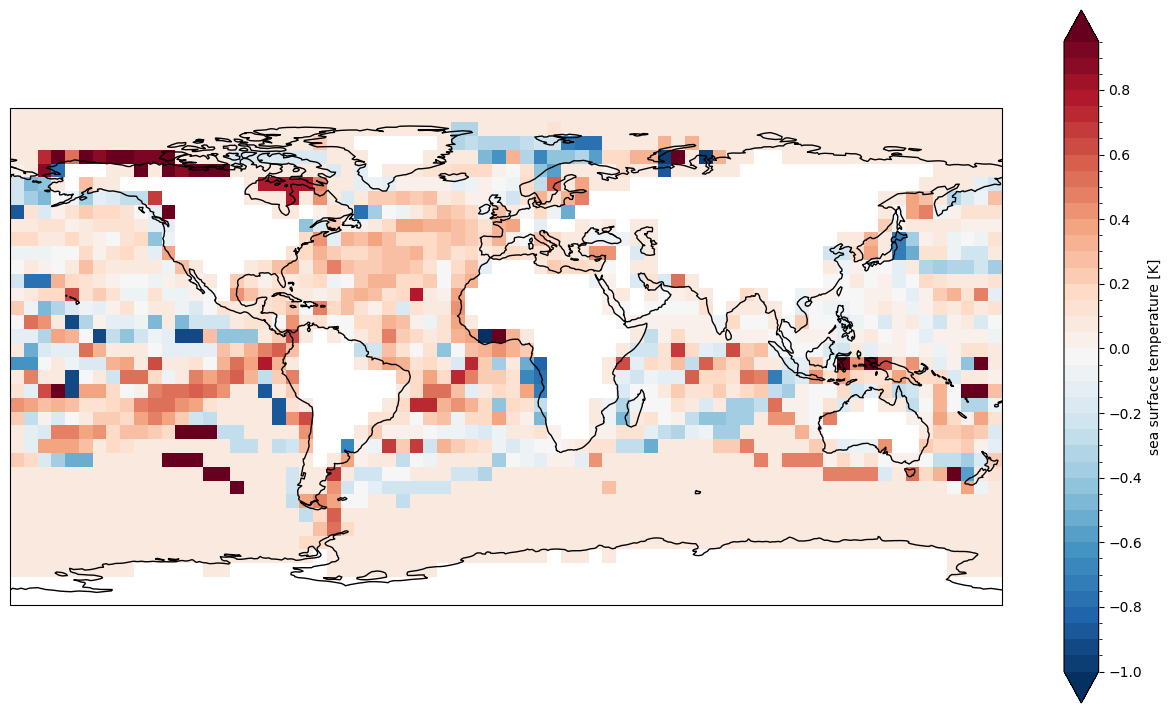

In [15]:
ship_bias_grid.plot_map_5x5(levels=np.arange(-1, 1, 0.05))

In [16]:
data_file = data_dir / "IQUAM" / "OutputData" / "timeseries_with_uncertainty.csv"
data = pd.read_csv(data_file, header=[0, 1], index_col=0)
time = np.arange(len(data)) / 12. + 1981 + 8 / 12.

ship = data['ship']['Global']
ship_unc = data['ship_unc']['Global']

drifter = data['drifter']['Global']
drifter_unc = data['drifter_unc']['Global']

argo = data['argo']['Global']
argo_unc = data['argo_unc']['Global']

interp = data['interp']['Global']
interp_unc = data['interp_unc']['Global']

Bias adjusted time series
=========================

By repeating the 2-step interpolation for every month it's possible to build up a time series that integrates information from the drifting buoys and ships in some kind of "optimal" way. One nice outcome of this is that the data are bias adjusted in the process. I put the prophylactic bunny ears on "optimal" because the whole thing requires fine tuning and it's only optimal in the sense that we got everything right, which is to say it's actually suboptimal.

(-0.5, 0.86)

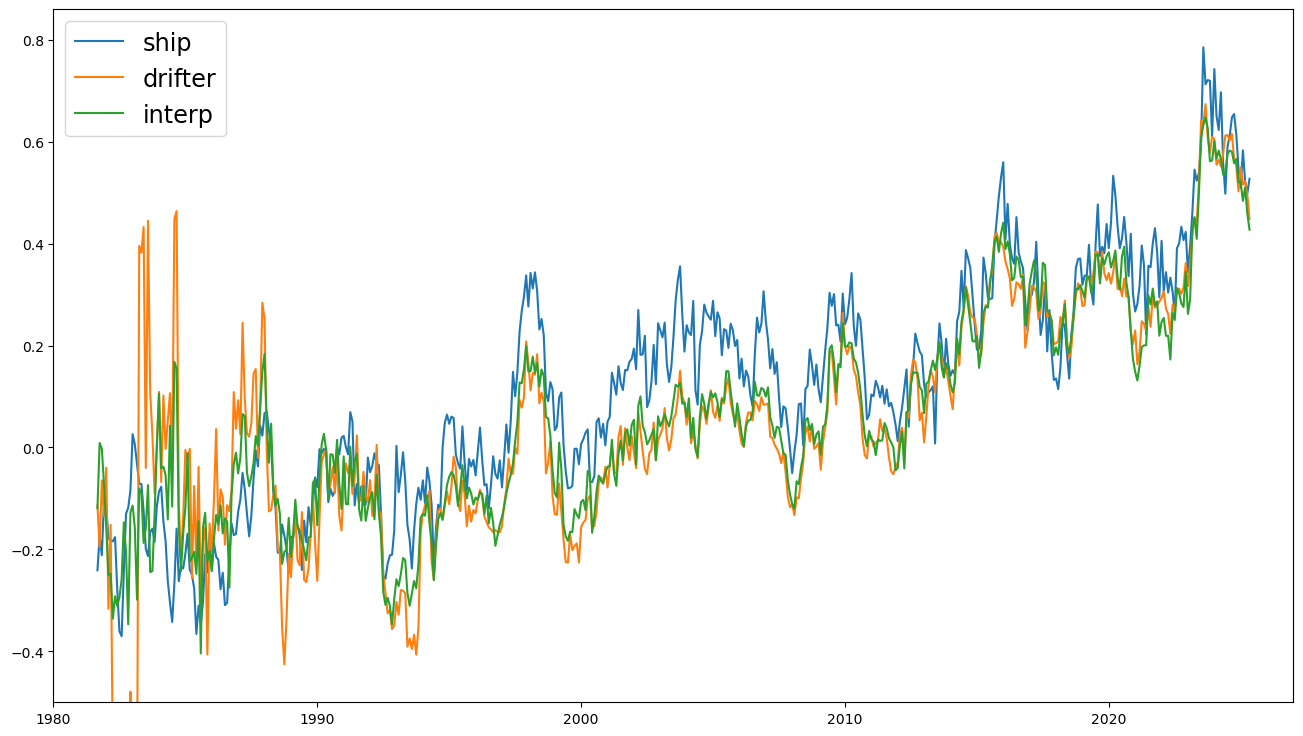

In [17]:
plt.figure()
plt.gcf().set_size_inches(16, 9)

plt.plot(time, ship, label='ship')
plt.plot(time, drifter, label='drifter')
plt.plot(time, interp, label='interp')

plt.legend(fontsize='xx-large')
plt.xlim(1980, 2027)
plt.ylim(-0.5, 0.86)

The interpolated data uses both ship and drifter data, but unlike the simple gridded combination of the two, the series now tends to follow the drifting buoy data throughout. Gridding them together without compensating for the bias in the ship data, leads to an artificial cooling in the combined dataset, but that should now be gone.

Of course, we might have other problems instead. In the 1980s, the coverage of the drifting buoys is far from global and those buoys that there are take fewer and noisier measurements. Ideally, we would use a different benchmark dataset to continue adjusting the data prior to the drifter era (ERSST uses marine air temperatures, HadSST4 uses oceanographic measurements). Also, I haven't yet included the moored buoy data in the interpolation and the Arctic Ocean has an unrealistically warm anomaly so I will need to do something about ice. There's ice up there which moderates the anomalies by pinning them close to whatever the freezing point of sea water happens to be.

In [18]:
climatology = xr.open_dataset(data_dir / "SST_CCI_climatology" / "SST_1x1_daily.nc")
cos_lat_weights = np.cos(np.deg2rad(climatology.latitude))

# Use the SST values in the climatology as an ocean mask. Set area to 1 for gridcells with SSTs, 0 otherwise
climatology = climatology.sst[0].values
ocean = np.where(np.isnan(climatology), 0.0, 1.0)

# Areas are proportional to the cosine of latitude multiplied by the ocean area in the grid cell
areas = np.zeros((36, 72))
for xx, yy in product(range(72), range(36)):
    areas[yy, xx] = np.mean(ocean[yy*5:(yy+1)*5, xx*5:(xx+1)*5]) * np.cos(np.pi*(yy*5 - 87.5)/180.)

# normalise the areas to one at the equator
areas = areas/np.max(areas)

hadsst4 = xr.open_dataset(data_dir / "ManagedData" / "Data" / "HadSST4" / "HadSST.4.1.1.0_median.nc")

lat_slice = hadsst4.tos.sel(latitude=slice(-90, 90))
lat_lon_slice = lat_slice.sel(longitude=slice(-180, 180))

weights = lat_lon_slice[0]
weights.values = areas

h4_weighted_mean = lat_lon_slice.weighted(weights).mean(("longitude", "latitude"))
h4_time = np.arange(len(h4_weighted_mean))/12. + 1850.

In [19]:
filepath = data_dir/ 'ERSSTv6'
files = filepath.glob('ersst.v6.*.nc')
ersst = xr.open_mfdataset(files)

In [ ]:
climatology = xr.open_dataset(data_dir / "SST_CCI_climatology" / "SST_1x1_daily.nc")
climatology = climatology.sst[0].values
ocean = np.where(np.isnan(climatology), 0.0, 1.0)
ocean = np.roll(ocean, 180, axis=1)
ersst_areas = np.zeros((89, 180))
for xx, yy in product(range(180), range(89)):
    ersst_areas[yy, xx] = np.mean(ocean[yy*2+1:(yy+1)*2+1, xx*2:(xx+1)*2]) * np.cos(np.pi*(yy*2 - 88.0)/180.)

In [29]:
lat_slice = ersst.ssta.sel(lat=slice(-90, 90))
lat_lon_slice = lat_slice.sel(lon=slice(0, 360))
weights = lat_lon_slice[0]
weights.values = np.reshape(ersst_areas, (1, 89, 180)) # ERSST has an extra lev dimension for some reason
ersst_weighted_mean = lat_lon_slice.weighted(weights).mean(("lon", "lat"))
ersst_time = np.arange(len(ersst_weighted_mean))/12. + 1850.


<xarray.Dataset> Size: 269MB
Dimensions:  (time: 2100, lev: 1, lat: 89, lon: 180)
Coordinates:
  * lat      (lat) float64 712B -88.0 -86.0 -84.0 -82.0 ... 82.0 84.0 86.0 88.0
  * lev      (lev) float64 8B 0.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 17kB 1850-01-15 1850-02-15 ... 2024-12-15
Data variables:
    sst      (time, lev, lat, lon) float32 135MB dask.array<chunksize=(1, 1, 89, 180), meta=np.ndarray>
    ssta     (time, lev, lat, lon) float32 135MB dask.array<chunksize=(1, 1, 89, 180), meta=np.ndarray>
Attributes: (12/70)
    Conventions:                     CF-1.6, ACDD-1.3
    metadata_link:                   https://doi.org/10.7289/V5T72FNM
    dataset_doi:                     https://doi.org/10.7289/V5T72FNM
    id:                              gov.noaa.ncdc:C00927
    naming_authority:                gov.noaa.ncei
    title:                           NOAA ERSSTv6 (in situ only)
    ...                

Comparison to HadSST4
=====================

We can compare this series to that from HadSST4. Previously, I compared the combined series to the unadjusted HadSST4, but here I'm going to compare to the adjusted version because we should have a series that is effectively homogenised. So, let's see.

(-0.5, 0.86)

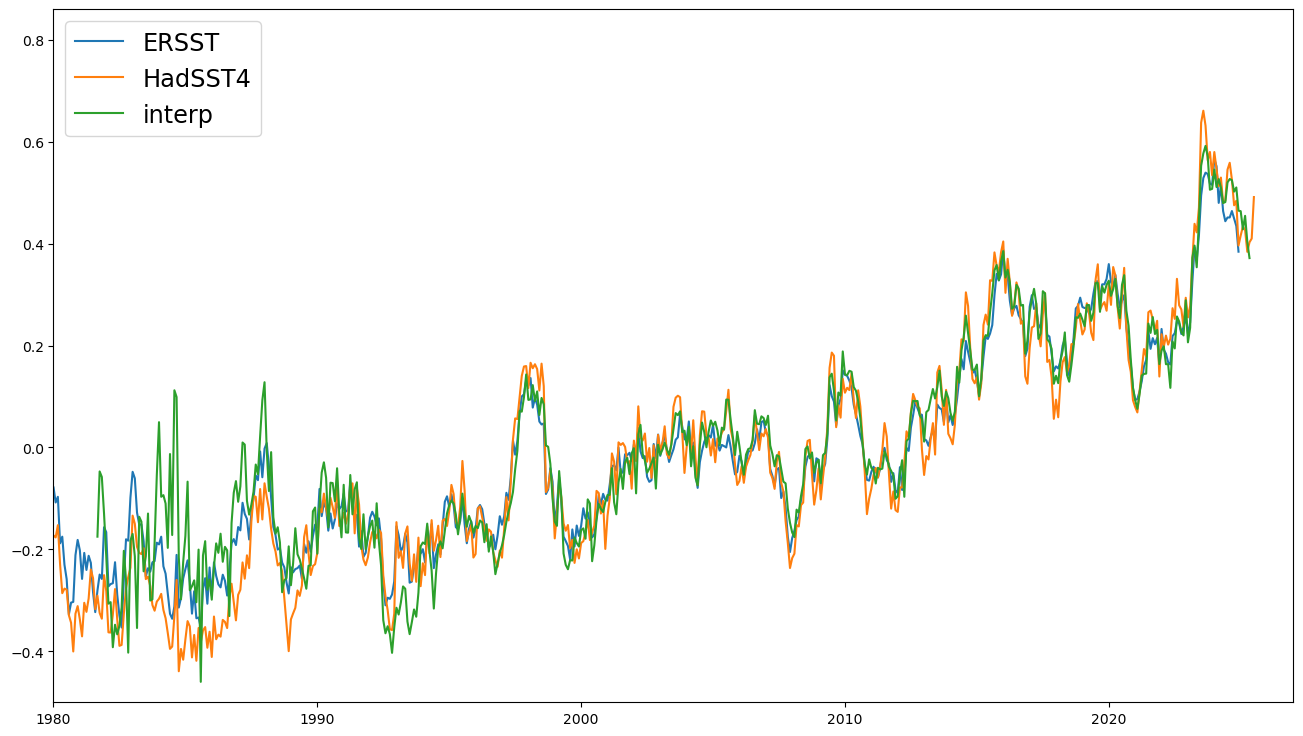

In [32]:
plt.figure()
plt.gcf().set_size_inches(16, 9)

selection = (time >= 1991) & (time <=2020)
hselection = (h4_time >= 1991) & (h4_time <=2020)
eselection = (ersst_time >= 1991) & (ersst_time <=2020)

plt.plot(ersst_time, ersst_weighted_mean - np.mean(ersst_weighted_mean[eselection]), label='ERSST')
plt.plot(h4_time, h4_weighted_mean - np.mean(h4_weighted_mean[hselection]), label='HadSST4')
plt.plot(time, interp - np.mean(interp[selection]), label='interp')

plt.legend(fontsize='xx-large')
plt.xlim(1980, 2027)
plt.ylim(-0.5, 0.86)

That's surprisingly close, I would say.

There are a couple of things to note. First, the coverage of the two data sets is different because HadSST4 is not interpolated so we might still expect some differences. Second, prior to 1995 or thereabouts, the two diverge. That's because HadSST4 uses subsurface data in addition to drifter data to benchmark the bias adjustments. In principle, HadSST4 is doing a better job. Third, the two are still referenced to different baselines. I've removed the average offset here, but not accounted for any seasonal effects.

For all that though, and despite being less sophisticated, this simple series looks to be doing quite a good job (since the mid 1990s anyway).